<a href="https://colab.research.google.com/github/SudoAlluri/Mental_Health_Analysis/blob/main/Grad_Ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Uploading files to Colab

To upload your `mental_health_dataset.xlsx` (or `.csv` if it's a CSV) file to your Colab session, you can use the following code:

*   Click the folder icon on the left sidebar to open the file browser.
*   Click the "Upload to session storage" icon (a page with an arrow pointing up) and select your file.

Alternatively, you can use the `files.upload()` function from `google.colab`:


In [1]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')


Saving mental_health_dataset.csv to mental_health_dataset.csv
User uploaded file "mental_health_dataset.csv" with length 608866 bytes


In [2]:
# All the necessary imports
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
import matplotlib.pyplot as plt

In [3]:
# Import the dataset file
data = pd.read_csv('mental_health_dataset.csv')

In [4]:
# Look at the data
data.head()

,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High


In [5]:
# Now we need to massage the data a little bit and prepare it for our nueral network
# The fourth and eight through eleven columns are good, they are numerical although NN like the
# data to be between 0 and 1 so we'll just scale them
# We need to "label encode" columns two through six


# age feature to float
x1 = np.array(data['age'], dtype = float)
x1 = x1/max(x1)

# stress level feature to float
x7 = np.array(data['stress_level'], dtype=float)
x7 = x7/max(x7)
# sleep hours feature to float which is already in float
x8= np.array(data['sleep_hours'], dtype=float)
x8= x8/max(x8)
# physical activity days to float
x9= np.array(data['physical_activity_days'], dtype=float)
x9= x9/max(x9)
# depression feature  to float
x10= np.array(data['depression_score'], dtype=float)
x10= x10/max(x10)
# anxiety feature to float
x11= np.array(data['anxiety_score'], dtype=float)
x11= (x11)/max(x11)
# social support to float
x12= np.array(data['social_support_score'], dtype=float)
x12= (x12)/max(x12)
# productivity sscore to float
x13= np.array(data['productivity_score'], dtype=float)
x13= (x13)/max(x13)


In [6]:
# Now we can encode the label columns
encoders = {}
gender_encoder = LabelEncoder()
x2 = data['gender']
x2 = gender_encoder.fit_transform(x2)
encoders['gender'] = gender_encoder
print(np.unique(x2)) # Looks like we have 4 different GENDERS
x2orig = x2
x2 = x2/max(x2)


#x2labels = gender_encoder.inverse_transform(x2orig)
#x2labels # This is how you get back to the original labels

employment_encoder = LabelEncoder()
x3 = data['employment_status']
x3 = employment_encoder.fit_transform(x3)
encoders['employment_status'] = employment_encoder
print(np.unique(x3)) # 4 different employemnt statuses
x3 = x3/max(x3)

environment_encoder = LabelEncoder()
x4 = data['work_environment']
x4 = environment_encoder.fit_transform(x4)
encoders['work_environment'] = environment_encoder
print(np.unique(x4)) # 3 different  labels
x4 = x4/max(x4)

mentalhealth_encoder = LabelEncoder()
x5 = data['mental_health_history']
x5 = mentalhealth_encoder.fit_transform(x5)
encoders['mental_health_history'] = mentalhealth_encoder

print(np.unique(x5)) # 2 categorical labels
x5 = x5/max(x5)

treatment_encoder = LabelEncoder()
x6 = data['seeks_treatment']
x6 = treatment_encoder.fit_transform(x6)
encoders['seeks_treatment'] = treatment_encoder

print(np.unique(x6)) # 2 categorical labels
x6 = x6/max(x6)

[0 1 2 3]
[0 1 2 3]
[0 1 2]
[0 1]
[0 1]


In [7]:
# since we are going to try and predict the mental health risk level then we'll also need to one-hot encode the mental health data
risk_encoder = LabelEncoder()
y = data['mental_health_risk']
y = risk_encoder.fit_transform(y)
yorig = y
onehot = OneHotEncoder(sparse_output=False)
y = onehot.fit_transform(y.reshape(-1, 1))
y.shape # What this does is it converts the column into an array where there is a row for each data point and the number
# of columns is the number of unique labels, if the label at that data point matches the risk_encoder there is a one
# in that element, if not then there is a zero. We need the y data to be this way so that implimenting the NN is easy

(10000, 3)

In [9]:
age_max = data['age'].max()
stress_level_max =data['stress_level'].max()
sleep_hours_max = data['sleep_hours'].max()
physical_activity_days_max = data['physical_activity_days'].max()
depression_score_max = data['depression_score'].max()
anxiety_score_max = data['anxiety_score'].max()
social_support_score_max = data['social_support_score'].max()
productivity_score_max = data['productivity_score'].max()

# Max encoded values for categorical features, observed from np.unique(encoded_feature).max()
gender_max_encoded = np.unique(x2orig).max()
employment_status_max_encoded = np.unique(x3).max()
work_environment_max_encoded = np.unique(x4).max()
mental_health_history_max_encoded = np.unique(x5).max()
seeks_treatment_max_encoded = np.unique(x6).max()

feature_max_values = {
    "age": age_max,
    "gender": gender_max_encoded,
    "employment_status": employment_status_max_encoded,
    "work_environment": work_environment_max_encoded,
    "mental_health_history": mental_health_history_max_encoded,
    "seeks_treatment": seeks_treatment_max_encoded,
    "stress_level": stress_level_max,
    "sleep_hours": sleep_hours_max,
    "physical_activity_days": physical_activity_days_max,
    "depression_score": depression_score_max,
    "anxiety_score": anxiety_score_max,
    "social_support_score": social_support_score_max,
    "productivity_score": productivity_score_max
}

# The order of features must match the order used when creating the training 'x' array
# which was: x1, x2, x3, x4,x5, x6, x7, x8, x9, x10, x11,x12,x13
feature_names_in_order = [
    "age", "gender", "employment_status", "work_environment",
    "mental_health_history", "seeks_treatment", "stress_level",
    "sleep_hours", "physical_activity_days", "depression_score",
    "anxiety_score", "social_support_score", "productivity_score"
]



In [10]:
x = np.stack((x1, x2, x3, x4, x5, x6, x7, x8, x9, x10, x11, x12, x13))
x = x.T
x.shape

(10000, 13)

### **Corelation matrixes**

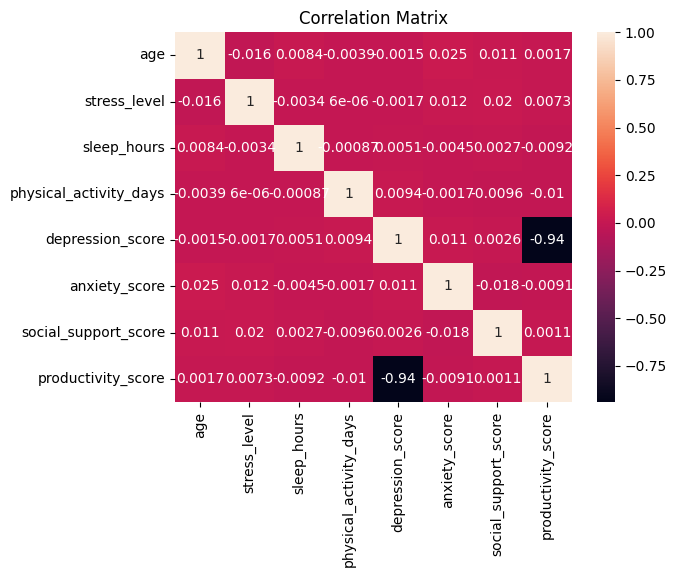

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns
num_cols = [
    'age', 'stress_level', 'sleep_hours',
    'physical_activity_days', 'depression_score',
    'anxiety_score', 'social_support_score',
    'productivity_score'
]

corr = data[num_cols].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

### **Train** **code**
Code for training x and y features

In [11]:
xTrain, xTest, yTrain, yTest = train_test_split(x, y, test_size = 0.20, random_state=42)
xTrain, xVal, yTrain, yVal = train_test_split(xTrain, yTrain, test_size = .33, random_state = 21)
print(xTrain.shape)
print(yTrain.shape)

(5360, 13)
(5360, 3)


In [12]:
model = Sequential()
model.add(Dense(256, input_shape=(13,), activation='relu')) # the number of weights (256) can be adjusted for performance
model.add(Dense(512, activation='relu')) # same here, 512 can be adjusted
model.add(Dense(256, activation='relu')) # same here
model.add(Dense(3, activation='softmax')) # for the last layer we want the number of weights to match the size of y (3) which high/medium/low risk with
# softmax activation since we are predicting classes this will result in a vector of probabilities in y
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 267,267 (1.02 MB)

 Trainable params: 267,267 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# As you can see above, our model is a dense NN with 3 layers and an output layer, we have 267,267 total trainable weights
# Now all we need to do is train these
# 1st we compile it we need to use catergorical crossentropy for the loss function, we'll use the "adam" optimizer, and the metric we want to track
# during training is accuracy
model.compile(loss = 'categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
# During training we'll use an epoch of 100. This means that the model will be fit 100 times.
epochN = 20
# Now we can call the model fit function
history = model.fit(x = xTrain, y = yTrain, epochs=epochN, validation_data=(xVal, yVal))

Epoch 1/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8576 - loss: 0.3229 - val_accuracy: 0.8754 - val_loss: 0.2722
Epoch 2/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9328 - loss: 0.1525 - val_accuracy: 0.9379 - val_loss: 0.1570
Epoch 3/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9424 - loss: 0.1352 - val_accuracy: 0.9545 - val_loss: 0.1044
Epoch 4/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9453 - loss: 0.1253 - val_accuracy: 0.9523 - val_loss: 0.0985
Epoch 5/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9504 - loss: 0.1082 - val_accuracy: 0.9477 - val_loss: 0.1133
Epoch 6/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9515 - loss: 0.1208 - val_accuracy: 0.9545 - val_loss: 0.0932
Epoch 7/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9552 - loss: 0.1052 - val_accuracy: 0.9553 - val_loss: 0.0943
Epoch 8/20
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9599 - loss: 0.0879 - val_accuracy: 0.

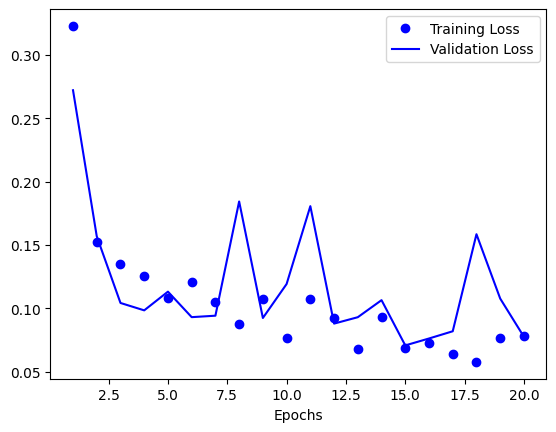

In [15]:
loss = history.history['loss']
valLoss = history.history['val_loss']
#acc = history.history['acc']
#valAcc = history.history['val_acc']
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, valLoss, 'b', label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.show()

In [16]:
loss, accuracy = model.evaluate(xTrain, yTrain, verbose=0)
print(f"Train Loss: {loss:.4f}")
print(f"Train Accuracy: {accuracy:.4f}")

Train Loss: 0.0376
Train Accuracy: 0.9873


### Evaluate Model Performance on Test Data

In [19]:
loss, accuracy = model.evaluate(xTest, yTest, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Test Loss: 0.0778
Test Accuracy: 0.9675


In [17]:
# Function to predict the unseen or new data by providing the feature details to predict the output feature value
def predict_risk(new_input):
    df = pd.DataFrame([new_input])
    # Label encode categorical columns using the pre-fitted encoders from global 'encoders' dict
    for col_name, encoder in encoders.items():
        if col_name in df.columns:
            df[col_name] = encoder.transform(df[col_name])

    # To ensure the DataFrame columns are in the correct order to match model's input features
    df_ordered = df[feature_names_in_order]
    X_new = df_ordered.values.astype(float)

    # Scale each feature manually using the pre-defined max_values, consistent with training data
    scaled_X_new = np.zeros_like(X_new, dtype=float)
    for i, feature_name in enumerate(feature_names_in_order):
        value = X_new[0, i]
        max_val = feature_max_values[feature_name]
        scaled_X_new[0, i] = value / max_val if max_val != 0 else value

    # Make prediction using the model trained on similarly scaled data
    pred = model.predict(scaled_X_new)
    pred_class = np.argmax(pred, axis=1)

    # Decode the predicted class back to the original risk label
    return risk_encoder.inverse_transform(pred_class)[0]


### Make Predictions and Visualize Results

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


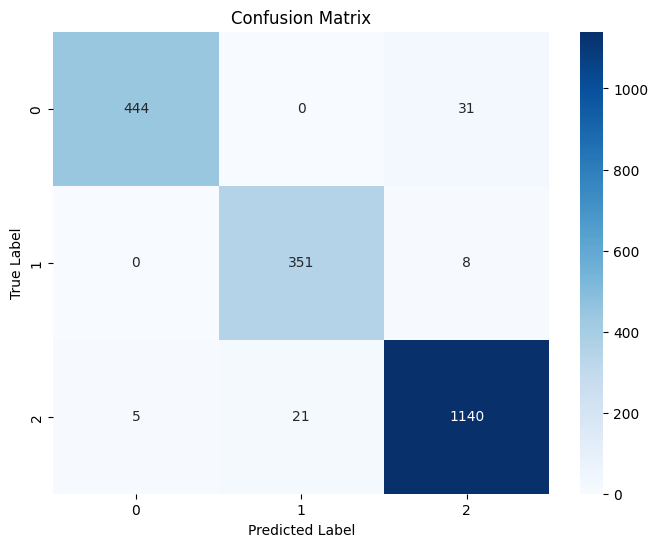


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.93      0.96       475
           1       0.94      0.98      0.96       359
           2       0.97      0.98      0.97      1166

    accuracy                           0.97      2000
   macro avg       0.97      0.96      0.96      2000
weighted avg       0.97      0.97      0.97      2000



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred_prob = model.predict(xTest)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true_classes = np.argmax(yTest, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Classification Report
print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes))


# Predict using new data

In [25]:
predict_risk({
    "age": 28,
    "gender": "Male",
    "employment_status": "Employed",
    "work_environment": "Remote",
    "mental_health_history": "No",
    "seeks_treatment": "Yes",
    "stress_level": 7,
    "sleep_hours": 5,
    "physical_activity_days": 4,
    "depression_score": 20,
    "anxiety_score": 13,
    "social_support_score": 4,
    "productivity_score": 10
})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


'High'

In [22]:
# Get predictions for X_test
y_pred = model.predict(xTest)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
